---
title: "A Statistics Primer"
subtitle: "DS 2023 | Communicating with Data"
---

## Overview

The plots in this unit all help you visualize the **distribution** of a single measurement variable.

To read them well, you need learn or recall a small set of statistical ideas.

Among the most basic ideas are the following:

| Idea | Where you will use it |
|---|---|
| Distributions: center, spread, shape | All four plots |
| Mean and median | Histograms, box plots |
| Standard deviation | Density plots, Q-Q plots |
| Quantiles and the IQR | Box plots, Q-Q plots |
| Counts, proportions, and densities | Histograms, density plots |
| The normal distribution and z-scores | Density plots, Q-Q plots |
| Samples and models | Density plots, Q-Q plots |
| Outliers | Box plots |

## Set up

To illustrate these concepts, we use the `tips` dataset.

Our running example is `total_bill`, the amount of each restaurant bill in dollars.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

tips = sns.load_dataset('tips')
S = tips['total_bill']
S.head()

0    16.99
1    10.34
2    21.01
3    23.68
4    24.59
Name: total_bill, dtype: float64

## 1. Distributions

A distribution describes **which values a variable takes and how often it takes each one**.

We describe a distribution by three kinds of properties:

- **Center**: Where is a typical value?
- **Spread**: How far do values stray from the center?
- **Shape**: Is the distribution symmetric or lopsided? Does it have one peak or several?

Each plot in this unit shows these properties in a different way.

```{note}
Distributions in this sense belong to measurement variables, meaning numbers on a scale where distances mean something.
Counting the values of a grouping variable is a bar chart's job.
```

## 2. Center: mean and median

The **mean** is the sum of the values divided by their number.

The **median** is the middle value once the values are sorted.
Half the data lie below it and half above.

In [14]:
S.mean(), S.median()

(np.float64(19.78594262295082), np.float64(17.795))

The two measures respond differently to extreme values.

Watch what happens when we add a single $\$500$ bill.

In [15]:
S_plus = pd.concat([S, pd.Series([500])])

pd.DataFrame({
    'original': [S.mean(), S.median()],
    'with one $500 bill': [S_plus.mean(), S_plus.median()]
}, index=['mean', 'median']).round(2)

,original,with one $500 bill
mean,19.79,21.75
median,17.80,17.81


The mean jumps by about $\$2$, while the median barely moves.

We say the median is **robust**: it resists extreme values.

```{important}
When the mean and median differ noticeably, the distribution is lopsided.
The mean gets pulled toward the long tail.
```

## 3. Spread: standard deviation

The **standard deviation** (SD) is, roughly, the typical distance of a value from the mean.

It is measured in the same units as the data, here dollars.

A small SD means the values cluster tightly, and a large SD means they are scattered.

In [16]:
S.std()

np.float64(8.902411954856856)

```{note}
You will also see the **variance**, which is the SD squared.
Its units are squared too (dollars squared), which is why we usually report the SD.
```

Like the mean, the SD is sensitive to extreme values.

## 4. Quantiles

A **quantile** is a cut point in the sorted data.

The $0.25$ quantile is the value with $25\%$ of the data below it.

When quantiles are expressed in percent, they are called **percentiles**.

Three quantiles get special names, the **quartiles**:

| Name | Quantile | Meaning |
|---|---|---|
| Q1 | $0.25$ | a quarter of the data lie below |
| Q2 | $0.50$ | the median |
| Q3 | $0.75$ | three quarters of the data lie below |

The distance from Q1 to Q3 is the **interquartile range** (IQR).
It is the spread of the middle half of the data.

In [17]:
Q1, Q2, Q3 = S.quantile([.25, .5, .75])
IQR = Q3 - Q1

print(f"Q1 = {Q1:.2f}, median = {Q2:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")

Q1 = 13.35, median = 17.80, Q3 = 24.13, IQR = 10.78


Quantiles are the robust counterparts of the mean and SD.

The median stands in for the mean, and the IQR stands in for the SD.

A **box plot** is a drawing of quantiles, and a **Q-Q plot** is a comparison of quantiles.

## 5. Shape

Shape has three parts.

**Modality** is the number of peaks.

One peak is **unimodal**, and two peaks are **bimodal**.

More than one peak often means the data mix several populations, as with the six countries in `healthexp`.

**Skew** is a long tail on one side.

In a **right-skewed** distribution, the tail stretches toward large values, and the mean sits above the median.

Money, durations, and sizes are often right-skewed, because they cannot go below zero but can grow large.

**Tails** describe how much data sits far from the center.

**Heavy** tails have more extreme values than a bell curve would predict, and **light** tails have fewer.

Here are three common shapes, drawn from simulated data.

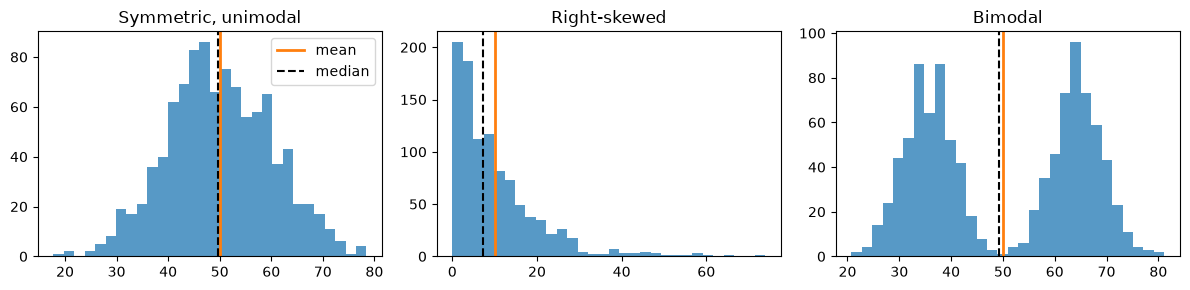

In [18]:
rng = np.random.default_rng(2023)

shapes = {
    'Symmetric, unimodal': rng.normal(50, 10, 1000),
    'Right-skewed': rng.exponential(10, 1000),
    'Bimodal': np.concatenate([rng.normal(35, 5, 500), rng.normal(65, 5, 500)])
}

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, (name, data) in enumerate(shapes.items()):
    ax[i].hist(data, bins=30, color='tab:blue', alpha=.75)
    ax[i].axvline(np.mean(data), c='tab:orange', lw=2, label='mean')
    ax[i].axvline(np.median(data), c='black', ls='--', label='median')
    ax[i].set_title(name)
ax[0].legend()
plt.tight_layout()
plt.show()

Notice the gap between the mean and median in the skewed panel.

In the bimodal panel, the mean and median fall in a valley where almost no data lie.
This is why a single summary number can describe none of the data.

Pandas can measure skew directly.
A value near 0 is symmetric, and a value beyond ±1 is strongly skewed.

In [19]:
S.skew()

np.float64(1.1332130376158205)

At about $1.1$, our bills are clearly right-skewed, which fits with the mean ($19.79$) sitting above the median ($17.80$).

## 6. Counts, proportions, and densities

The y axis of a histogram can show three different things.

- A **count** (or frequency) is the number of values in each bin.
- A **proportion** is the count divided by the total, so the bars sum to $1$.
- A **density** is the proportion divided by the bin width, so the *areas* of the bars sum to $1$.

Density matters because it does not depend on how many bins you choose.
That is what lets you compare histograms with different bins, or draw a density curve over a histogram.

```{important}
On a density scale, read **area**, not height.
Height tells you how concentrated the data are, and area tells you how much of the data lies in a range.
```

```{note}
The Histograms notebook builds all three versions of the y axis from scratch.
```

## 7. The normal distribution

The **normal distribution** is the familiar bell curve.

It is symmetric, and two numbers fully define it: its mean and its standard deviation.

It matters here because it is the usual **reference model**.
Many measurements are roughly normal, and Q-Q plots most often compare data against it.

A handy fact about any normal distribution is the **68–95–99.7 rule**:

- about $68\%$ of values fall within $1$ SD of the mean,
- about $95\%$ fall within $2$ SDs,
- about $99.7\%$ fall within $3$ SDs.

### z-scores

A **z-score** says how many SDs a value lies from the mean:

$$z = \frac{x - \text{mean}}{\text{SD}}$$

Converting to z-scores puts any variable on a common, unit-free scale.

Let's use z-scores to check whether our bills follow the 68–95–99.7 rule.

In [20]:
z = (S - S.mean()) / S.std()

pd.DataFrame({
    'bills': [(z.abs() < k).mean() for k in [1, 2, 3]],
    'normal': [.68, .95, .997]
}, index=['within 1 SD', 'within 2 SD', 'within 3 SD']).round(3)

,bills,normal
within 1 SD,0.721,0.680
within 2 SD,0.943,0.950
within 3 SD,0.984,0.997


The numbers are close to the normal ones, but not exact.

A picture shows where they differ.
Here we overlay a normal curve with the same mean and SD as the bills.

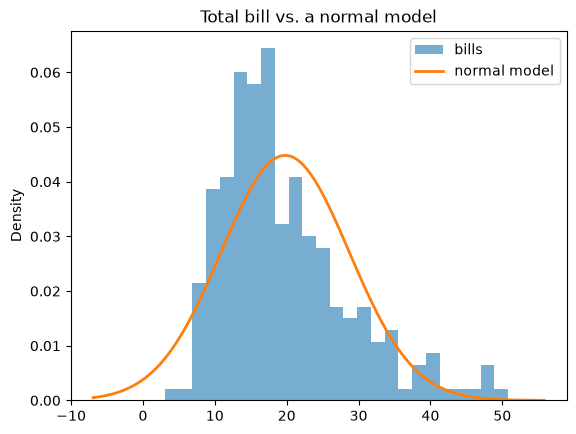

In [21]:
x = np.linspace(S.min() - 10, S.max() + 5, 200)

S.plot.hist(bins=25, density=True, alpha=.6, label='bills')
plt.plot(x, stats.norm.pdf(x, S.mean(), S.std()), c='tab:orange', lw=2, label='normal model')
plt.ylabel('Density')
plt.legend()
plt.title("Total bill vs. a normal model")
plt.show()

The model puts too much weight on small bills, including impossible negative ones, and too little on the long right tail.

That mismatch is exactly what a Q-Q plot is designed to expose.

## 8. Samples and models

A dataset is a **sample**, a subset of some larger **population** we never see in full.

When we plot a sample, we are really trying to see the shape of the population behind it.

A **model** is an assumed distribution, such as the normal, that we compare a sample against.

A KDE curve is also a kind of model, a smooth guess at the population's shape.

The key practical point is that **small samples are noisy**.

Below are four samples of 20 values, each drawn from the *same* normal distribution.

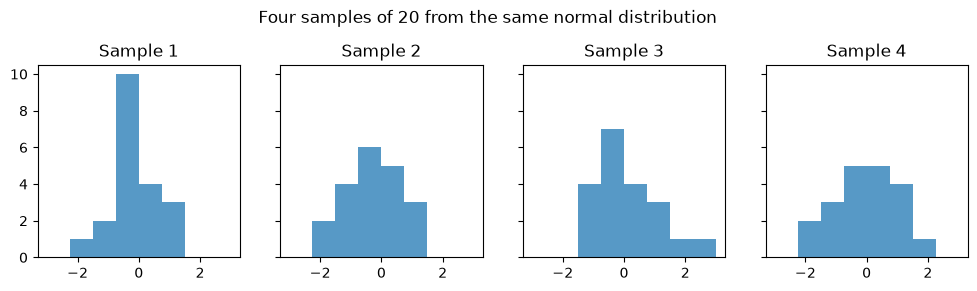

In [22]:
fig, ax = plt.subplots(1, 4, figsize=(12, 2.5), sharey=True)
for i in range(4):
    ax[i].hist(rng.normal(0, 1, 20), bins=8, range=(-3, 3), color='tab:blue', alpha=.75)
    ax[i].set_title(f"Sample {i + 1}")
plt.suptitle("Four samples of 20 from the same normal distribution", y=1.1)
plt.show()

None of the samples looks like a clean bell curve, and some appear skewed or bimodal.

```{caution}
With small samples, don't read much into bumps, gaps, or lopsidedness.
Shape judgments become trustworthy only as the sample grows.
```

## 9. Outliers

An **outlier** is a value unusually far from the rest of the data.

"Unusually far" has no universal definition, so we need a rule.
Box plots use **Tukey's rule**, which flags any value more than 1.5 × IQR beyond the quartiles:

- lower fence = Q1 − $1.5$ × IQR
- upper fence = Q3 + $1.5$ × IQR

In [23]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Fences: {lower:.2f} to {upper:.2f}")
S[(S < lower) | (S > upper)].sort_values().to_list()

Fences: -2.82 to 40.30


[40.55, 41.19, 43.11, 44.3, 45.35, 48.17, 48.27, 48.33, 50.81]

These are the dots you would see beyond the whiskers of a box plot of `total_bill`.

Note that the lower fence is negative, so no bill can be a low outlier.
This is another symptom of right skew.

```{tip}
An outlier is a prompt to look closer, not an error to delete.
It may be a typo, or it may be the most interesting observation in the dataset.
```

## 10. Theoretical quantiles

The last idea you need is specific to the Q-Q plot.

Section 4 found quantiles of our *data*.

A model has quantiles too.

The model's **quantile function** takes a proportion $p$ and returns the value that has $p$ of the model below it.

For the standard normal (mean $0$, SD $1$), SciPy provides `stats.norm.ppf`.

In [24]:
stats.norm.ppf([.025, .25, .5, .75, .975]).round(2)

array([-1.96, -0.67,  0.  ,  0.67,  1.96])

For example, $2.5\%$ of a standard normal lies below $−1.96$, and $97.5\%$ lies below $+1.96$.

A Q-Q plot pairs each sorted data value with the model quantile at the same $p$.

If the data have the model's shape, the pairs fall on a straight line.

Here is a minimal version for our bills, using the z-scores from Section 7.

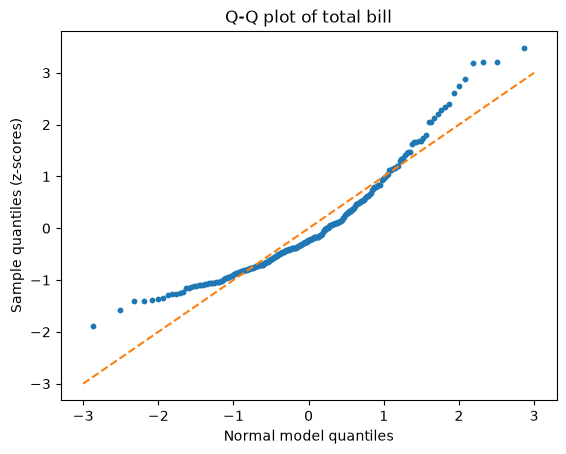

In [25]:
n = len(z)
p = (np.arange(1, n + 1) - .5) / n      # evenly spaced proportions
model_q = stats.norm.ppf(p)             # where a normal sample would put them
sample_q = np.sort(z)                   # where our data actually are

plt.scatter(model_q, sample_q, s=10)
plt.plot([-3, 3], [-3, 3], c='tab:orange', ls='--')
plt.xlabel("Normal model quantiles")
plt.ylabel("Sample quantiles (z-scores)")
plt.title("Q-Q plot of total bill")
plt.show()

The points form a curve that bends up at both ends.

At the left end, the smallest bills sit above the line, because bills can't fall far below the mean.

At the right end, the largest bills rise well above the line, because they are more extreme than a normal model predicts.

Together, these two ends are the signature of the right skew we have seen all along.

A few patterns cover most of what you will see:

| Pattern | Meaning |
|---|---|
| Points on the line | Shape matches the model |
| Both ends bend up (a convex curve) | Right skew |
| Both ends bend down (a concave curve) | Left skew |
| Ends flare away from the line (an S shape) | Heavy tails |
| Ends pull in toward the line | Light tails |
| Horizontal steps | Discrete values (many ties) |

## Summary

| Plot | What it shows | Ideas you need | Watch out for |
|---|---|---|---|
| Histogram | How many values fall in each bin | Distributions; center, spread, and shape; counts vs. density | The number of bins changes the picture |
| Density plot | A smooth estimate of the distribution's shape | Density (read area, not height); samples and models | Bandwidth; small samples; hard limits like zero |
| Box plot | The median, quartiles, and outliers | Quantiles; IQR; Tukey's rule | Hides the number of peaks |
| Q-Q plot | How the data's shape departs from a model | Quantiles; the normal distribution; z-scores | Judge straightness, not position |